# Transfer Learning con PyTorch

Entrenar CNNs desde cero requiere grandes cantidades de datos y tiempo de cómputo. Gran parte de ese esfuerzo se invierte en aprender filtros de bajo nivel que son útiles para cualquier tarea de visión. Surge entonces una pregunta natural: ¿podemos reutilizar una red entrenada en un dataset y adaptarla a una tarea diferente sin repetir el proceso completo?

Eso es precisamente **transfer learning**: transferimos el conocimiento de un modelo preentrenado (generalmente en **ImageNet**) a nuestra tarea específica. Las capas convolucionales ya saben extraer bordes, texturas y formas genéricas; nosotros solo necesitamos adaptar la cabeza de clasificación.

En este notebook exploraremos tres estrategias:
1. Extracción de features con el backbone congelado
2. Reemplazar el clasificador final y entrenar solo esa parte
3. Fine-tuning: descongelar gradualmente el backbone


## 0. Imports y configuración


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torchinfo import summary
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image
import glob

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando device: {device}')


Usando device: cuda


## 1. Funciones auxiliares

Definimos aquí las utilidades que usaremos a lo largo del notebook: verificación del dataset, visualización de muestras, y el loop de entrenamiento con logging a TensorBoard.


In [42]:
def check_image_dir(pattern):
    """Elimina imágenes corruptas que coincidan con el patrón glob."""
    removed = 0
    for fname in glob.glob(pattern):
        try:
            img = Image.open(fname)
            img.verify()
        except Exception:
            print(f'Eliminando archivo corrupto: {fname}')
            os.remove(fname)
            removed += 1
    print(f'{pattern}: {removed} archivos eliminados')


def display_dataset(dataset, n=10):
    """Muestra n imágenes aleatorias del dataset con su etiqueta."""
    indices = np.random.choice(len(dataset), n, replace=False)
    fig, axes = plt.subplots(2, n // 2, figsize=(15, 5))
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    for ax, idx in zip(axes.flat, indices):
        img, label = dataset[idx]
        img = (img * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        title = dataset.classes[label] if hasattr(dataset, 'classes') else str(label)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def train_epoch(model, loader, optimizer, loss_fn):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct += (out.argmax(1) == y).sum().item()
        total += len(y)
    return total_loss / total, correct / total


def eval_epoch(model, loader, loss_fn):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = loss_fn(out, y)
            total_loss += loss.item() * len(y)
            correct += (out.argmax(1) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total


def train(
    model, train_loader, test_loader,
    loss_fn=None, optimizer=None,
    epochs=5, lr=1e-3, writer=None, tag=''
):
    if loss_fn is None:
        loss_fn = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()), lr=lr
        )
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, loss_fn)
        va_loss, va_acc = eval_epoch(model, test_loader, loss_fn)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        if writer:
            writer.add_scalars(f'{tag}/Loss', {'train': tr_loss, 'val': va_loss}, epoch)
            writer.add_scalars(f'{tag}/Acc',  {'train': tr_acc,  'val': va_acc},  epoch)
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {tr_loss:.4f} acc {tr_acc:.4f} | '
              f'val loss {va_loss:.4f} acc {va_acc:.4f}')
    return history


def plot_results(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train', marker='o')
    ax1.plot(history['val_loss'],   label='val', marker='o')
    ax1.set_title('Loss'); ax1.legend()
    ax2.plot(history['train_acc'], label='train', marker='o')
    ax2.plot(history['val_acc'],   label='val', marker='o')
    ax2.set_title('Accuracy'); ax2.legend()
    plt.tight_layout()
    plt.show()

print('Funciones auxiliares definidas ✓')


Funciones auxiliares definidas ✓


## 2. Dataset: Cats vs. Dogs

Usaremos el [Kaggle Cats vs. Dogs Dataset](https://www.kaggle.com/c/dogs-vs-cats), también disponible [desde Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Es un conjunto clásico de ~25 000 imágenes de gatos y perros, ideal para experimentar con transfer learning porque el dominio (fotografías naturales) coincide con ImageNet.


In [3]:
import zipfile

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/kagglecatsanddogs_5340.zip'):
    !wget -P data https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

if not os.path.exists('data/PetImages'):
    with zipfile.ZipFile('data/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
        zip_ref.extractall('data')


--2026-09-24 17:39:31--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.32.118.60, 2600:1402:9800:592::317f, 2600:1402:9800:586::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.32.118.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘data/kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   253MB/s    in 3.1s    

2026-09-24 17:39:34 (253 MB/s) - ‘data/kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



El dataset contiene algunas imágenes corruptas. Las eliminamos antes de construir el `Dataset`:


In [4]:
check_image_dir('data/PetImages/Cat/*.jpg')
check_image_dir('data/PetImages/Dog/*.jpg')


Eliminando archivo corrupto: data/PetImages/Cat/666.jpg
data/PetImages/Cat/*.jpg: 1 archivos eliminados


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Eliminando archivo corrupto: data/PetImages/Dog/11702.jpg
data/PetImages/Dog/*.jpg: 1 archivos eliminados


### Transforms y normalización

Los modelos preentrenados en ImageNet esperan imágenes de **224 × 224** píxeles normalizadas con la media y desviación estándar del dataset de entrenamiento original:

```
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]
```

Usar estos valores es fundamental: si los activamos con distribuciones de entrada distintas, los pesos preentrenados producirán representaciones incorrectas.

> **TODO 1:** Completa el pipeline de transforms. Debe redimensionar a 256, recortar al centro 224 × 224, convertir a tensor y aplicar la normalización.


Total de imágenes: 24998 | Clases: ['Cat', 'Dog']
Train: 20000 | Test: 4998


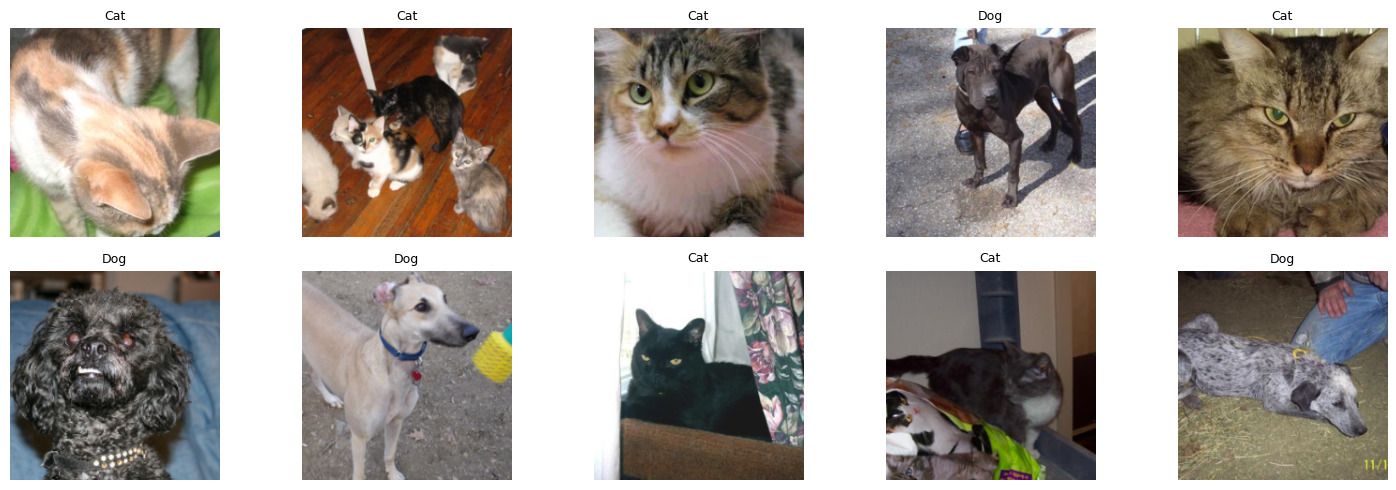

In [5]:
std_normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std =[0.229, 0.224, 0.225]
)

# TODO 1: Define `trans` como un transforms.Compose con los pasos indicados arriba
trans = None

trans = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    std_normalize
])

# --- no modificar desde aquí ---
assert trans is not None, 'Debes definir el pipeline de transforms'
dataset = torchvision.datasets.ImageFolder('data/PetImages', transform=trans)
print(f'Total de imágenes: {len(dataset)} | Clases: {dataset.classes}')

trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(trainset)} | Test: {len(testset)}')
display_dataset(dataset)


## 3. Modelos preentrenados

`torchvision.models` incluye decenas de arquitecturas con pesos preentrenados en ImageNet. Cargamos VGG-16 y lo usamos directamente para hacer una inferencia sobre una imagen del dataset:


In [6]:
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

sample_image, _ = dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

with torch.no_grad():
    res = vgg(sample_image)

print(f'Shape de salida: {res.shape}')  # [1, 1000]
print(f'Clase predicha (índice ImageNet): {res[0].argmax().item()}')


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 163MB/s]  


Shape de salida: torch.Size([1, 1000])
Clase predicha (índice ImageNet): 281


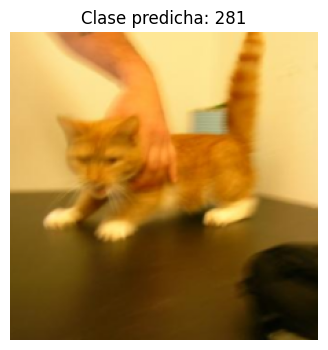

In [7]:
# Visualizar la imagen
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

img_show = (sample_image.squeeze(0).cpu() * std + mean).clamp(0, 1)
img_show = img_show.permute(1, 2, 0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img_show)
plt.title(f'Clase predicha: {res[0].argmax().item()}')
plt.axis('off')
plt.show()

La red devuelve un índice de clase de ImageNet. Podemos descargar el mapeo para ver el nombre de la predicción:


In [8]:
import json, requests

class_map = json.loads(
    requests.get('https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json').text
)
class_map = {int(k): v for k, v in class_map.items()}

pred_idx = res[0].argmax().item()
print(f'Clase predicha: {class_map[pred_idx]}')


Clase predicha: ['n02123045', 'tabby']


### Arquitectura de VGG-16

Inspeccionemos la arquitectura completa con `torchinfo.summary`. Fíjate en el número total de parámetros y en los tipos de capas que aparecen:


In [9]:
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 1000]                 --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         1,792
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         36,928
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        73,856
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        147,584
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]          29

Además de las capas convolucionales y de pooling que ya conoces, observarás capas **Dropout**. Actúan como técnica de **regularización**: durante el entrenamiento desactivan aleatoriamente una fracción de las neuronas de la capa anterior, lo que obliga a la red a aprender representaciones más robustas y distribuidas.

La arquitectura se divide en tres partes:
- `vgg.features` — el extractor convolucional
- `vgg.avgpool` — pooling adaptativo
- `vgg.classifier` — capas densas que mapean 25 088 features → 1 000 clases

> **Pregunta:** ¿Por qué la última capa tiene exactamente 1 000 salidas?


## 4. Extracción de features

Podemos usar `vgg.features` como extractor fijo: pasamos imágenes, obtenemos tensores de representación, y luego entrenamos un clasificador pequeño encima de esos vectores. Así evitamos reentrenar toda la red.

Primero visualicemos los mapas de activación de la última capa convolucional:


Shape del tensor de features: torch.Size([1, 512, 7, 7])


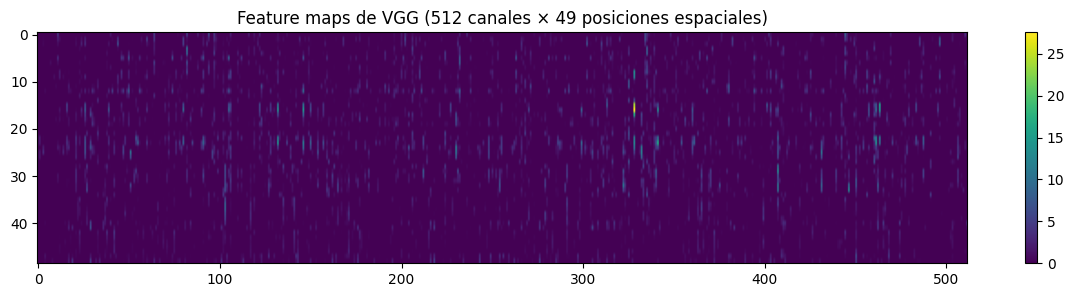

In [10]:
with torch.no_grad():
    feat = vgg.features(sample_image).cpu()

print(f'Shape del tensor de features: {feat.shape}')  # [1, 512, 7, 7]

plt.figure(figsize=(15, 3))
plt.imshow(feat.squeeze().view(512, -1).T, aspect='auto', cmap='viridis')
plt.title('Feature maps de VGG (512 canales × 49 posiciones espaciales)')
plt.colorbar()
plt.show()


Ahora pre-computamos los feature vectors para un subconjunto de 800 imágenes. Almacenamos los resultados en tensores para poder entrenar el clasificador sin recalcular features en cada epoch.

> **TODO 2:** Completa el loop de extracción. Inicializa `feature_tensor` de shape `[num, 512*7*7]` y `label_tensor` de shape `[num]`, luego llena ambos tensores dentro del bucle.


In [30]:
bs  = 8
num = bs * 100  # 800 imágenes
dl  = torch.utils.data.DataLoader(dataset, batch_size=bs, shuffle=True)

# TODO 2: Inicializa feature_tensor y label_tensor
feature_tensor = torch.zeros((num, 512* 7* 7))  # shape [num, 512*7*7]
label_tensor   = torch.zeros(num)  # shape [num]

i = 0
for x, l in dl:
    with torch.no_grad():
        # TODO 2 (cont.): extrae features, aplana y almacena en los tensores
        with torch.no_grad():
            x = x.to(device)
            feat = vgg.features(x)
            feature_tensor[i:i+bs] = feat.view(bs, -1)
            label_tensor[i:i+bs] = l
        pass
    i += bs
    print('.', end='')
    if i >= num:
        break

print(f'\nfeature_tensor: {feature_tensor.shape} | label_tensor: {label_tensor.shape}')


....................................................................................................
feature_tensor: torch.Size([800, 25088]) | label_tensor: torch.Size([800])


## 5. Clasificador lineal sobre features fijas

Con los feature vectors pre-computados, entrenamos un clasificador de una sola capa lineal. Esto es extremadamente rápido porque no hay que hacer backprop a través de la CNN.

La función de pérdida estándar para clasificación multiclase en PyTorch es `CrossEntropyLoss`, que internamente aplica softmax. Por eso la red **no debe** incluir una capa de activación final — la red devuelve logits crudos.

> **TODO 3:** Define `net` como un `nn.Sequential` con una sola capa `Linear` de `512*7*7` entradas y `2` salidas.


Epoch 01/5 | train loss 0.2943 acc 0.8914 | val loss 0.0697 acc 0.9700
Epoch 02/5 | train loss 0.0163 acc 0.9943 | val loss 0.0819 acc 0.9600
Epoch 03/5 | train loss 0.0004 acc 1.0000 | val loss 0.0716 acc 0.9700
Epoch 04/5 | train loss 0.0002 acc 1.0000 | val loss 0.0721 acc 0.9700
Epoch 05/5 | train loss 0.0001 acc 1.0000 | val loss 0.0724 acc 0.9700


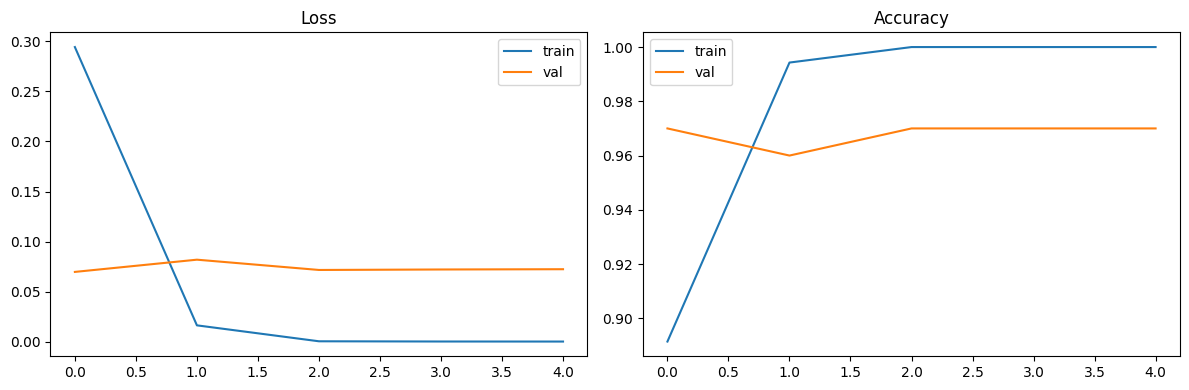

In [32]:
vgg_dataset = torch.utils.data.TensorDataset(
    feature_tensor,
    label_tensor.to(torch.long)
)
train_ds, test_ds = torch.utils.data.random_split(vgg_dataset, [700, 100])
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32)
test_loader  = torch.utils.data.DataLoader(test_ds,  batch_size=32)

# TODO 3: Define net — una Linear(512*7*7, 2) es suficiente con CrossEntropyLoss
net = nn.Sequential(nn.Linear(512*7*7, 2))
net = net.to(device)

writer  = SummaryWriter('runs/linear_classifier')
history = train(net, train_loader, test_loader, epochs=5, writer=writer, tag='linear')
writer.close()
plot_results(history)


## 6. Transfer learning — Reemplazar el clasificador

En lugar de pre-computar features, podemos conectar directamente nuestra cabeza de clasificación al backbone de VGG y entrenar el modelo end-to-end. Para ello:

1. **Reemplazamos `vgg.classifier`** por una sola capa `Linear(25088, 2)`.
2. **Congelamos `vgg.features`** poniendo `requires_grad = False` en todos sus parámetros.    Esto es importante: si entrenamos end-to-end desde el principio, los errores grandes    del clasificador aleatorio destruirían los pesos preentrenados del extractor.

> **TODO 4:** Carga VGG-16 con pesos preentrenados, reemplaza el clasificador y congela las capas convolucionales.


In [36]:
# TODO 4a: Carga VGG-16 con pesos preentrenados
vgg = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.DEFAULT)
vgg = vgg.to(device)

# TODO 4b: Reemplaza vgg.classifier por Linear(25088, 2)
vgg.classifier = nn.Linear(25088, 2).to(device)

# TODO 4c: Congela los parámetros de vgg.features
for param in vgg.features.parameters():
    param.requires_grad = False

# Verifica: solo el clasificador debe tener parámetros entrenables
summary(vgg, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [1, 2]                    --
├─Sequential: 1-1                        [1, 512, 7, 7]            --
│    └─Conv2d: 2-1                       [1, 64, 224, 224]         (1,792)
│    └─ReLU: 2-2                         [1, 64, 224, 224]         --
│    └─Conv2d: 2-3                       [1, 64, 224, 224]         (36,928)
│    └─ReLU: 2-4                         [1, 64, 224, 224]         --
│    └─MaxPool2d: 2-5                    [1, 64, 112, 112]         --
│    └─Conv2d: 2-6                       [1, 128, 112, 112]        (73,856)
│    └─ReLU: 2-7                         [1, 128, 112, 112]        --
│    └─Conv2d: 2-8                       [1, 128, 112, 112]        (147,584)
│    └─ReLU: 2-9                         [1, 128, 112, 112]        --
│    └─MaxPool2d: 2-10                   [1, 128, 56, 56]          --
│    └─Conv2d: 2-11                      [1, 256, 56, 56]    

El summary debe mostrar aproximadamente **50 000 parámetros entrenables** (solo los pesos de la capa lineal).

Entrenamos con el dataset completo. Este proceso toma bastante tiempo; se recomienda GPU:


Epoch 01/1 | train loss 0.2379 acc 0.9751 | val loss 0.3757 acc 0.9754


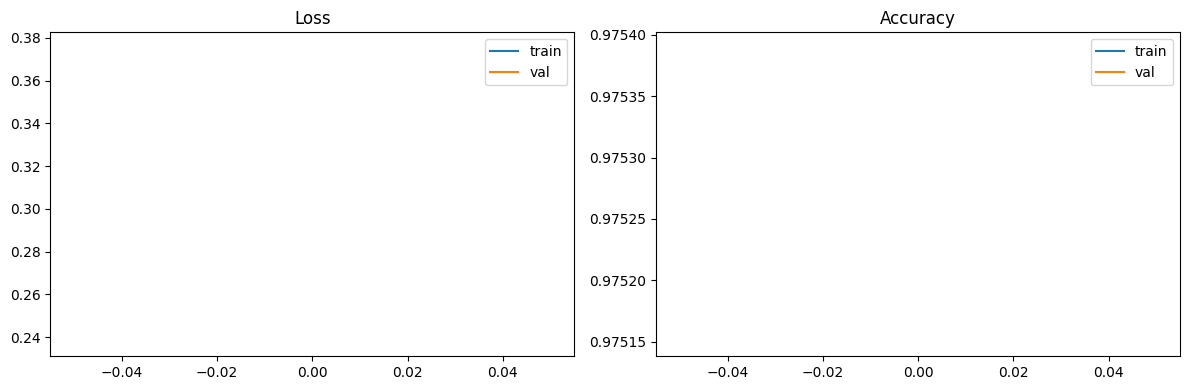

Modelo guardado ✓


In [37]:
trainset, testset = torch.utils.data.random_split(
    dataset, [20000, len(dataset) - 20000],
    generator=torch.Generator().manual_seed(42)
)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=16, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(testset,  batch_size=16, num_workers=2, pin_memory=True)

writer = SummaryWriter('runs/transfer_frozen')
history_frozen = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-3,
    writer=writer, tag='frozen'
)
writer.close()
plot_results(history_frozen)


torch.save(vgg.state_dict(), 'data/cats_dogs_weights.pth')
print('Modelo guardado ✓')



## 7. Fine-tuning — Descongelar el backbone

Una vez que el clasificador tiene pesos razonables, podemos descongelar las capas convolucionales y continuar entrenando toda la red con un **learning rate más pequeño**. Esto permite que el extractor se especialice en nuestro dominio.

> ⚠️ Si descongelamos desde el principio (sin estabilizar primero el clasificador), los gradientes grandes del clasificador aleatorio pueden degradar los pesos preentrenados.

> **TODO 5:** Descongela los parámetros de `vgg.features` y entrena una epoch adicional con `lr=1e-4`.


In [ ]:
### training con data augmentation
train_trans = transforms.Compose([ 
    transforms.RandomResizedCrop(224), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10), 
    transforms.ToTensor(), 
    std_normalize 
])

# Same split as before, but train images go through train_trans
train_base = torchvision.datasets.ImageFolder(dataset.root, transform=train_trans)
trainset_aug = torch.utils.data.Subset(train_base, trainset.indices)

train_loader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=16, shuffle=True, num_workers=2, pin_memory=True)
# test_loader stays unchanged: testset still uses `trans` (no augmentation)

#And the fine-tuning block with the backbone unfrozen:

vgg = torchvision.models.vgg16(weights=None)
vgg.classifier = nn.Linear(25088, 2)
vgg.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg = vgg.to(device)

# TODO 5: Descongela vgg.features
for param in vgg.features.parameters():
    param.requires_grad = True

writer = SummaryWriter('runs/transfer_finetuned_aug')
history_ft = train(
    vgg, train_loader_aug, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-4,
    writer=writer, tag='finetuned_aug'
)
writer.close()
plot_results(history_ft)

In [ ]:
vgg = torchvision.models.vgg16(weights=None)
vgg.classifier = nn.Linear(25088, 2)
vgg.load_state_dict(torch.load('data/cats_dogs_weights.pth', weights_only=True))
vgg = vgg.to(device)

# Transforms para enriquecimiento de data
train_trans = transforms.Compose([ 
    transforms.RandomResizedCrop(224), 
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10), 
    transforms.ToTensor(), 
    std_normalize 
])

train_loader

# TODO 5: Descongela vgg.features
for param in vgg.features.parameters():
    param.requires_grad = True

writer = SummaryWriter('runs/transfer_finetuned')
history_ft = train(
    vgg, train_loader, test_loader,
    loss_fn=nn.CrossEntropyLoss(),
    epochs=1, lr=1e-4,
    writer=writer, tag='finetuned'
)
writer.close()
plot_results(history_ft)


## 8. Otras arquitecturas: ResNet

`torchvision.models` incluye muchas más redes preentrenadas. Una de las familias más usadas es **ResNet** (Microsoft Research), que resuelve el problema del gradiente desvaneciente en redes profundas mediante **conexiones residuales** (*skip connections*): cada bloque aprende una corrección a su entrada en lugar de una transformación desde cero.

Exploremos ResNet-18, la versión más ligera de la familia:


## resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(resnet18)


Observa que la estructura es análoga a VGG: un extractor de features y una capa final de clasificación, aunque aquí se llama `fc` en lugar de `classifier`. También aparecen capas de **Batch Normalization** (`BatchNorm2d`), que normalizan las activaciones dentro de cada minibatch para estabilizar el entrenamiento.

> **TODO 6:** Adapta ResNet-18 para Cats vs. Dogs siguiendo el mismo esquema de la sección 6:
> 1. Congela todos los parámetros.
> 2. Reemplaza `resnet18.fc` por la capa adecuada (investiga cuántas entradas tiene).
> 3. Entrena 2 epochs y compara la velocidad y accuracy con VGG.


Epoch 01/2 | train loss 0.1249 acc 0.9519 | val loss 0.0576 acc 0.9784
Epoch 02/2 | train loss 0.0990 acc 0.9618 | val loss 0.0548 acc 0.9792


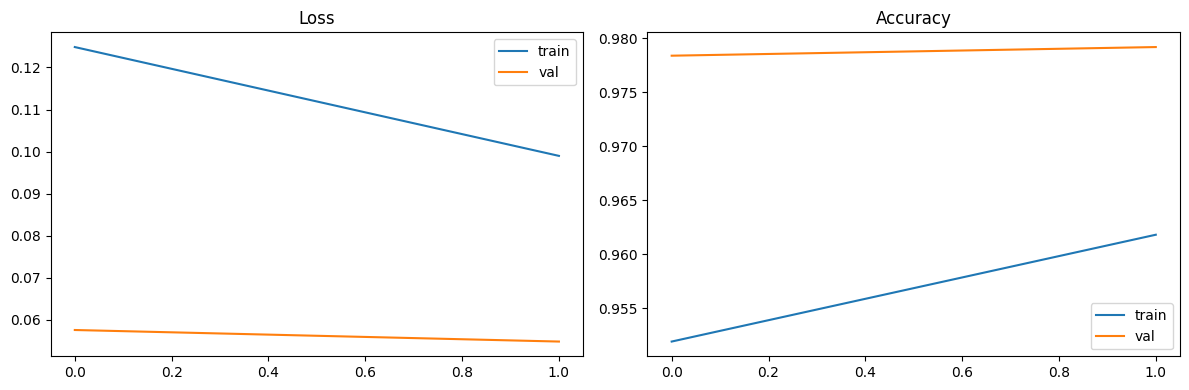

In [40]:
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)

# TODO 6a: Congela todos los parámetros
for param in resnet18.parameters():
    param.requires_grad = False

# TODO 6b: Reemplaza resnet18.fc
resnet18.fc = nn.Linear(resnet18.fc.in_features, 2).to(device) #(512, 2)

# TODO 6c: Entrena
writer = SummaryWriter('runs/resnet18')
history_rn = train(resnet18, train_loader, test_loader, epochs=2, writer=writer, tag='resnet18')
writer.close()
plot_results(history_rn)

## 9. Comparación de experimentos con TensorBoard

Todos los experimentos anteriores escribieron logs en el directorio `runs/`. TensorBoard permite comparar curvas de loss y accuracy de todos los experimentos en un mismo panel:


In [41]:
# En terminal:
!tensorboard --logdir=runs --port=6006

# En Jupyter / Colab:
#%load_ext tensorboard
#%tensorboard --logdir runs


/usr/local/lib/python3.12/dist-packages/tensorboard/default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources

NOTE: Using experimental fast data loading logic. To disable, pass
    "--load_fast=false" and report issues on GitHub. More details:
    https://github.com/tensorflow/tensorboard/issues/4784

Serving TensorBoard on localhost; to expose to the network, use a proxy or pass --bind_all
TensorBoard 2.20.0 at http://localhost:6006/ (Press CTRL+C to quit)
^C


## 10. Preguntas de investigación

Responde en celdas Markdown apoyándote en la documentación, papers o experimentos propios.

1. **Normalización ImageNet:** ¿De dónde vienen exactamente los valores `mean=[0.485, 0.456, 0.406]` y `std=[0.229, 0.224, 0.225]`? ¿Qué pasaría si usaras otros valores?

**R//** Los valores dados son valores calculados de las imagenes de entrenamiento (ImageNet). Representarian la media y la desviación estandar de los 3 cananales(Rojo, verde, azul).
- Si se usan otros valores las imagenes tendrian una distribución diferente y los pesos que ya habia aprendido pueden funcionar peor.

2. **CrossEntropyLoss vs NLLLoss:** Investiga la diferencia entre `nn.CrossEntropyLoss`, `nn.NLLLoss` y `nn.LogSoftmax`. ¿Por qué no debes añadir `LogSoftmax` a la red si ya usas `CrossEntropyLoss`?

**R//**  `nn.CrossEntropyLoss` recibe directamente los valores que salen de la red, llamados logits. Internamente hace el cálculo de `nn.LogSoftmax` y después `nn.NLLLoss`.
- `nn.NLLLoss` necesita recibir los valores que ya pasaron por `nn.LogSoftmax`.
- Por eso, si usamos `CrossEntropyLoss`, no debemos poner `LogSoftmax` al final de la red, porque estaríamos haciendo ese cálculo dos veces. En nuestro caso la red debe entregar los logits directamente.

3. **Data augmentation:** ¿Qué transforms adicionales añadirías al pipeline de entrenamiento para mejorar la generalización? Impleméntalos y mide el impacto en TensorBoard.

**R//** El data augmentation sirve para crear pequeñas variaciones de las imágenes de entrenamiento. Así la red no aprende simplemente a memorizar las imágenes y puede generalizar mejor.


train_trans = transforms.Compose([ transforms.RandomResizedCrop(224), 
                                transforms.RandomHorizontalFlip(), 
                                transforms.RandomRotation(10), 
                                transforms.ToTensor(), 
                                std_normalize ])
                            
- Esto hace que durante el entrenamiento la red vea imágenes ligeramente diferentes. Es una estrategia usada normalmente en transfer learning para mejorar la generalización.
Para medir el impacto, compararía en TensorBoard el experimento original contra el experimento con augmentation, mirando principalmente val_acc y val_loss. Si la accuracy de validación mejora y la diferencia entre entrenamiento y validación disminuye, sería una señal positiva.


4. **Learning rate scheduling:** Investiga `torch.optim.lr_scheduler.StepLR` y `CosineAnnealingLR`. Agrega uno al loop de fine-tuning y compara las curvas.

**R//* StepLR reduce el learning rate cada cierto número de épocas. Por ejemplo, podemos hacer que se reduzca a la mitad cada 2 épocas.

- CosineAnnealingLR va reduciendo el learning rate poco a poco siguiendo una curva. Esto permite empezar con un learning rate más alto y terminar con uno más pequeño.

5. **Límites del transfer learning:** ¿En qué situaciones transfer learning desde ImageNet podría no ser beneficioso? Da al menos dos ejemplos concretos.

**R//** Transfer learning no siempre funciona bien. Por ejemplo:

- Si las imágenes son muy diferentes a las de ImageNet. Por ejemplo, imágenes médicas como radiografías, donde las características importantes son diferentes a las fotografías normales.
- Si tenemos muchísimos datos propios y una tarea muy específica, puede ser mejor entrenar o adaptar un modelo de otra forma en vez de depender tanto de las características aprendidas en ImageNet.

En general, transfer learning funciona especialmente bien cuando el problema nuevo tiene características parecidas a las imágenes con las que se entrenó el modelo.

## 11. Preguntas taller
1. ¿De dónde vienen esos valores de media y std? ¿Por qué es importante usarlos si vas a
cargar pesos preentrenados?

Son el promedio y la variación de color que tienen las fotos de ImageNet (el dataset gigante con el que se entrenó VGG-16). La red aprendió a ver imágenes con esos valores. Si le das imágenes normalizadas distinto, es como si le cambiaras el lente: ya no reconoce bien lo que ve.

2. ¿Cuántos parámetros tiene VGG-16 en total? ¿Qué hace la capa Dropout y por qué
mejora la generalización? ¿Por qué la última capa tiene 1000 salidas?

VGG-16 tiene aprox 138 millones de parámetros en total (la gran mayoría,123M, están en las capas classifier totalmente conectadas solo el primer Linear(25088→4096) ya aporta 102M). Dropout desactiva aleatoriamente una fracción de neuronas (típicamente p=0.5) en cada paso de entrenamiento, forzando a la red a no depender de coactivaciones específicas de unidades concretas, esto reduce el co-adaptamiento y actúa como un ensamble implícito de subredes, mejorando la generalización. La última capa tiene 1000 salidas porque VGG-16 se entrenó para clasificar las 1000 clases del reto.

3. ¿Por qué es importante congelar las capas convolucionales antes de entrenar el nuevo
clasificador?

Los filtros convolucionales ya codifican características genéricas (bordes, texturas, formas) útiles para casi cualquier tarea visual,no hace falta reaprenderlas desde cero.

El clasificador nuevo empieza con pesos aleatorios, si entrenas todo junto, los gradientes grandes del clasificador recién inicializado se propagan hacia atrás y pueden destruir los pesos preentrenados antes de que el clasificador converja.
Congelar reduce drásticamente el número de parámetros entrenables lo que conduce a entrenamiento más rápido, menos memoria, y menor riesgo de overfitting si el dataset nuevo es pequeño.


4. ¿Qué es un residual block? ¿Qué problema resuelve en redes muy profundas? ¿ResNet-
18 entrena más rápido que VGG? ¿Por qué?


Un residual block calcula y = F(x) + x en vez de aprender la transformación completa, aprende el residuo respecto a la entrada, y una conexión de atajo (skip connection) suma la entrada original a la salida del bloque. Esto resuelve el problema del gradiente desvaneciente/degradación en redes muy profundas.
Sin skip connections, apilar más capas puede empeorar el entrenamiento (no solo por overfitting, sino porque el gradiente se atenúa al retropropagarse por muchas capas)
Con ellas, el gradiente tiene un camino directo hacia atrás, permitiendo entrenar redes de decenas o cientos de capas de forma estable.
Sobre velocidad: ResNet-18 tiene muchos menos parámetros (aprox 11.7M) que VGG-16 (aprox 138M), y usa convoluciones más eficientes (sin las capas fully-connected gigantescas de VGG), así que sí, en general entrena y hace inferencia más rápido por forward/backward pass, aunque sea "más profunda" en número de capas.


5. ¿Cuándo NO conviene usar transfer learning? Da al menos dos escenarios concretos.

- Dominio muy distinto al de ImageNet: imágenes médicas (rayos X, resonancias), imágenes satelitales, espectrogramas de audio convertidos a imagen, etc. Los filtros de bajo nivel aprendidos en fotos naturales (bordes, texturas de objetos cotidianos) no siempre transfieren bien a estos dominios muy diferentes.
   
- Dataset objetivo enorme y con recursos de cómputo suficientes: si tienes millones de ejemplos propios y GPU de sobra, entrenar desde cero puede superar al transfer learning, porque el modelo aprende representaciones específicamente optimizadas para tu tarea sin el sesgo de ImageNet.


6. ¿Por qué ResNet usa BatchNorm y VGG no? ¿Qué efecto tiene en el entrenamiento?
VGG-16 se publicó en 2014, antes de que BatchNorm se popularizara (2015). ResNet, al ser mucho más profunda, necesita BatchNorm para poder entrenarse de forma estable: BatchNorm normaliza las activaciones de cada mini-batch (media 0, varianza 1) antes de la no-linealidad, lo que reduce el internal covariate shift, permite usar learning rates más altos, acelera la convergencia y actúa como regularizador leve. Sin BatchNorm, apilar tantas capas (18, 34, 50+) sería mucho más inestable de entrenar. Existen versiones VGG con BatchNorm (vgg16_bn) que sí la incorporan y entrenan más rápido y estable que la original.

8. Investiga StepLR y CosineAnnealingLR. Agrega uno al loop de fine-tuning de la Actividad 5 y
compara curvas en TensorBoard.
9. ¿Por qué ResNet usa BatchNorm y VGG no? ¿Qué efecto tiene en el entrenamiento?
10. Normalización ImageNet: ¿De dónde vienen exactamente los valores mean=[0.485, 0.456,
0.406] y std=[0.229, 0.224, 0.225]? ¿Qué pasaría si usaras otros valores?
11. CrossEntropyLoss vs NLLLoss: Investiga la diferencia
entre nn.CrossEntropyLoss, nn.NLLLoss y nn.LogSoftmax. ¿Por qué no debes
añadir LogSoftmax a la red si ya usas CrossEntropyLoss?
12. Learning rate scheduling: Investiga torch.optim.lr_scheduler.StepLR y CosineAnnealingLR.
Agrega uno al loop de fine-tuning y compara las curvas.
13. Reto opcional: Usa EfficientNet-B0 (disponible en torchvision.models) y compara accuracy
final y tiempo de entrenamiento contra ResNet-18 y VGG-16